<a href="https://colab.research.google.com/github/thecoderwithHat/BPE-_Tokenizer_indic/blob/main/FineWeb2_hin_BPE_Tok.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install -q datasets

from datasets import load_dataset

print("Loading Croatian FineWeb-2 dataset (streaming)...")
# Get Croatian data
fw = load_dataset("HuggingFaceFW/fineweb-2", name="hin_Deva", split="train", streaming=True)

# Extract a chunk of text to train our tokenizer (e.g., first 1000 documents)
print("Extracting training corpus...")
corpus_texts = []
for i, example in enumerate(fw):
    corpus_texts.append(example["text"])
    if i >= 999:  # Collect 1000 documents
        break

croatian_text = "\n".join(corpus_texts)
print(f"Corpus loaded: {len(croatian_text)} characters.")
print(f"Sample:\n{croatian_text[:200]}...")

Loading Croatian FineWeb-2 dataset (streaming)...


README.md:   0%|          | 0.00/329k [00:00<?, ?B/s]

Extracting training corpus...
Corpus loaded: 2251738 characters.
Sample:
चीन में एक समय चोरों का बड़ा आतंक था. राज्य की राजधानी में ची युंग नामक एक व्यक्ति था जो किसी भी व्यक्ति का चेहरा देखकर यह बता देता था कि वह व्यक्ति चोर है या नहीं. सामनेवाले व्यक्ति के मुखमंडल के कुछ...


In [4]:
import re
import unicodedata
from collections import defaultdict
import time

class PureIndicTokenizer:
    def __init__(self, special_tokens=None):
        self.special_tokens = special_tokens or ["[PAD]", "[UNK]", "[BOS]", "[EOS]"]
        self.special_token_to_id = {tok: i for i, tok in enumerate(self.special_tokens)}

        self.merges = {}      # Maps (token1, token2) -> merged_token
        self.merges_rank = {} # Maps (token1, token2) -> priority rank
        self.vocab = {}       # Maps token (tuple/str) -> ID
        self.inv_vocab = {}   # Maps ID -> token (tuple/str)

    def normalize(self, text):
        # NFKC Normalization maps visually identical characters to standard byte representations
        return unicodedata.normalize('NFKC', text)

    def pre_tokenize(self, text):
        # Feature 4: Devanagari-Aware Regex Pre-tokenizer
        # Keeps Devanagari scripts [\u0900-\u097F], words, whitespace, and punctuation intact
        pattern = r'[\u0900-\u097F]+|[a-zA-Z0-9_]+|\s+|[^\w\s]'
        return re.findall(pattern, text, re.UNICODE)

    def train(self, text, num_merges=1000):
        print("Normalizing and pre-tokenizing corpus...")
        start_time = time.time()
        text = self.normalize(text)
        words = self.pre_tokenize(text)

        word_freqs = defaultdict(int)
        for word in words:
            # Skip splitting if word is a special token
            if word in self.special_token_to_id:
                continue
            byte_tokens = tuple((b,) for b in word.encode('utf-8'))
            word_freqs[byte_tokens] += 1

        print(f"Initial unique pre-tokens: {len(word_freqs)}")

        # BPE Merge Loop
        for i in range(num_merges):
            pair_counts = defaultdict(int)
            for byte_tokens, freq in word_freqs.items():
                for j in range(len(byte_tokens) - 1):
                    pair = (byte_tokens[j], byte_tokens[j+1])
                    pair_counts[pair] += freq

            if not pair_counts:
                break

            best_pair = max(pair_counts, key=pair_counts.get)
            new_token = best_pair[0] + best_pair[1]

            self.merges[best_pair] = new_token
            self.merges_rank[best_pair] = i

            new_word_freqs = defaultdict(int)
            for byte_tokens, freq in word_freqs.items():
                j = 0
                new_byte_tokens = []
                while j < len(byte_tokens):
                    if j < len(byte_tokens) - 1 and byte_tokens[j] == best_pair[0] and byte_tokens[j+1] == best_pair[1]:
                        new_byte_tokens.append(new_token)
                        j += 2
                    else:
                        new_byte_tokens.append(byte_tokens[j])
                        j += 1
                new_word_freqs[tuple(new_byte_tokens)] = freq

            word_freqs = new_word_freqs

        # Build Vocabulary mapping
        vocab_idx = 0

        # 1. Add Special Tokens first (IDs 0, 1, 2, 3...)
        for tok in self.special_tokens:
            self.vocab[tok] = vocab_idx
            self.inv_vocab[vocab_idx] = tok
            vocab_idx += 1

        # 2. Add 256 Base UTF-8 Bytes
        for b in range(256):
            self.vocab[(b,)] = vocab_idx
            self.inv_vocab[vocab_idx] = (b,)
            vocab_idx += 1

        # 3. Add Merged BPE Tokens
        for pair, merged in self.merges.items():
            if merged not in self.vocab:
                self.vocab[merged] = vocab_idx
                self.inv_vocab[vocab_idx] = merged
                vocab_idx += 1

        print(f"Training complete in {time.time() - start_time:.2f} seconds. Final Vocab Size: {vocab_idx}")

    def encode(self, text, add_special_tokens=False):
        text = self.normalize(text)
        words = self.pre_tokenize(text)

        token_ids = []
        if add_special_tokens and "[BOS]" in self.special_token_to_id:
            token_ids.append(self.special_token_to_id["[BOS]"])

        for word in words:
            if word in self.special_token_to_id:
                token_ids.append(self.special_token_to_id[word])
                continue

            byte_tokens = [(b,) for b in word.encode('utf-8')]

            while len(byte_tokens) > 1:
                pairs = [(byte_tokens[i], byte_tokens[i+1]) for i in range(len(byte_tokens)-1)]
                valid_pairs = {p: self.merges_rank[p] for p in pairs if p in self.merges_rank}
                if not valid_pairs:
                    break

                best_pair = min(valid_pairs, key=valid_pairs.get)

                new_byte_tokens = []
                j = 0
                while j < len(byte_tokens):
                    if j < len(byte_tokens) - 1 and byte_tokens[j] == best_pair[0] and byte_tokens[j+1] == best_pair[1]:
                        new_byte_tokens.append(best_pair[0] + best_pair[1])
                        j += 2
                    else:
                        new_byte_tokens.append(byte_tokens[j])
                        j += 1
                byte_tokens = new_byte_tokens

            for t in byte_tokens:
                if t in self.vocab:
                    token_ids.append(self.vocab[t])
                else:
                    unk_id = self.special_token_to_id.get("[UNK]", 1)
                    token_ids.append(unk_id)

        if add_special_tokens and "[EOS]" in self.special_token_to_id:
            token_ids.append(self.special_token_to_id["[EOS]"])

        return token_ids

    def decode(self, token_ids):
        flat_bytes = bytearray()
        decoded_parts = []

        for tid in token_ids:
            item = self.inv_vocab.get(tid)
            if isinstance(item, str):  # Special token
                if flat_bytes:
                    decoded_parts.append(flat_bytes.decode('utf-8', errors='replace'))
                    flat_bytes = bytearray()
                decoded_parts.append(item)
            elif isinstance(item, tuple):  # Byte tuple
                flat_bytes.extend(item)

        if flat_bytes:
            decoded_parts.append(flat_bytes.decode('utf-8', errors='replace'))

        return "".join(decoded_parts)

In [5]:
# Initialize and train tokenizer
indic_tokenizer = PureIndicTokenizer(special_tokens=["[PAD]", "[UNK]", "[BOS]", "[EOS]"])
indic_tokenizer.train(croatian_text, num_merges=1000)

Normalizing and pre-tokenizing corpus...
Initial unique pre-tokens: 35773
Training complete in 228.78 seconds. Final Vocab Size: 1260


In [7]:
!pip install -q transformers tabulate

from transformers import AutoTokenizer
from tabulate import tabulate

# Load baseline English-centric tokenizer for comparison
gpt2_tokenizer = AutoTokenizer.from_pretrained("gpt2")

# Croatian test sentence
test_text = "कृत्रिम बुद्धिमत्ता कंप्यूटर विज्ञान की एक शाखा है जो मशीनों को मानव जैसी बुद्धिमत्ता प्रदर्शित करने में सक्षम बनाती है।"

# 1. Raw UTF-8 Encoding (Absolute worst-case sequence length)
raw_bytes = list(test_text.encode('utf-8'))

# 2. Baseline GPT-2 Encoding
gpt2_tokens = gpt2_tokenizer.encode(test_text)

# 3. Our Custom Scratch Encoding
custom_tokens = indic_tokenizer.encode(test_text)
decoded_custom = indic_tokenizer.decode(custom_tokens)

# Verify Lossless Reconstruction
assert test_text == decoded_custom, "Decoding did not match original text!"

# Metrics Calculation
text_bytes = len(raw_bytes)

def get_metrics(name, tokens):
    token_count = len(tokens)
    bytes_per_token = text_bytes / token_count if token_count > 0 else 0
    reduction = ((len(raw_bytes) - token_count) / len(raw_bytes)) * 100
    return [name, token_count, round(bytes_per_token, 2), f"{round(reduction, 2)}%"]

results = [
    get_metrics("Raw UTF-8 Bytes (No BPE)", raw_bytes),
    get_metrics("GPT-2 Tokenizer", gpt2_tokens),
    get_metrics("Custom Hindi Tokenizer (Scratch)", custom_tokens)
]

# Display
print("\n" + "="*80)
print("TOKENIZER EVALUATION METRICS ON HINDI TEXT")
print("="*80)
print(f"Test Sentence: {test_text}\n")
print(tabulate(results, headers=["Tokenizer System", "Token Sequence Length", "Bytes packed per Token", "Length Reduction (vs Raw)"], tablefmt="github"))


TOKENIZER EVALUATION METRICS ON HINDI TEXT
Test Sentence: कृत्रिम बुद्धिमत्ता कंप्यूटर विज्ञान की एक शाखा है जो मशीनों को मानव जैसी बुद्धिमत्ता प्रदर्शित करने में सक्षम बनाती है।

| Tokenizer System                 |   Token Sequence Length |   Bytes packed per Token | Length Reduction (vs Raw)   |
|----------------------------------|-------------------------|--------------------------|-----------------------------|
| Raw UTF-8 Bytes (No BPE)         |                     322 |                     1    | 0.0%                        |
| GPT-2 Tokenizer                  |                     195 |                     1.65 | 39.44%                      |
| Custom Hindi Tokenizer (Scratch) |                      65 |                     4.95 | 79.81%                      |


In [8]:
def visualize_tokenization(tokenizer, text, add_special_tokens=True):
    token_ids = tokenizer.encode(text, add_special_tokens=add_special_tokens)
    visual_output = []

    for tid in token_ids:
        chunk = tokenizer.decode([tid])
        visual_output.append(f"[{chunk}]")

    print("=" * 80)
    print("VISUAL TOKENIZATION BREAKDOWN")
    print("=" * 80)
    print("Original Text:\n", text)
    print("\nToken IDs:\n", token_ids)
    print("\nVisual Token Chunks:\n", "".join(visual_output))
    print("=" * 80)

# Run Visualizer on test Hindi sentence
sample_sentence = "कृत्रिम बुद्धिमत्ता कंप्यूटर विज्ञान की एक शाखा है।"
visualize_tokenization(indic_tokenizer, sample_sentence, add_special_tokens=True)

VISUAL TOKENIZATION BREAKDOWN
Original Text:
 कृत्रिम बुद्धिमत्ता कंप्यूटर विज्ञान की एक शाखा है।

Token IDs:
 [2, 711, 382, 271, 274, 36, 654, 573, 271, 274, 383, 313, 36, 800, 670, 584, 36, 333, 1132, 36, 300, 36, 352, 36, 296, 1204, 262, 36, 337, 3]

Visual Token Chunks:
 [[BOS]][कृ][त्र][ि][म][ ][बु][द्ध][ि][म][त्][ता][ ][कंप][्यू][टर][ ][वि][ज्ञान][ ][की][ ][एक][ ][श][ाख][ा][ ][है।][[EOS]]



TOKENIZER FERTILITY & COMPRESSION BENCHMARKS (VALIDATION SET)
| System                  |   Total Tokens |   Fertility (Tokens/Word) ↓ |   Bytes/Token ↑ |
|-------------------------|----------------|-----------------------------|-----------------|
| Raw UTF-8 Bytes         |            904 |                       14.58 |            1    |
| GPT-2 (English-centric) |            541 |                        8.73 |            1.67 |
| Custom Hindi BPE        |            183 |                        2.95 |            4.94 |




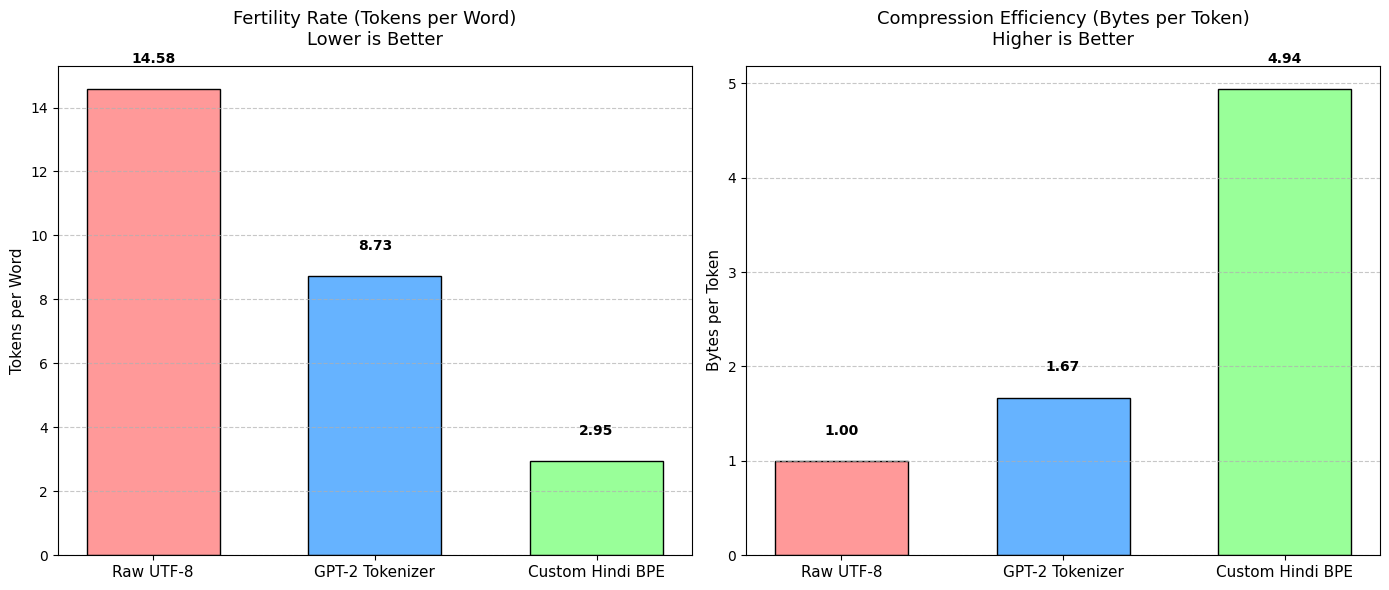

In [9]:
!pip install -q transformers tabulate matplotlib numpy

import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoTokenizer
from tabulate import tabulate

# Load baseline tokenizer for comparison
gpt2_tokenizer = AutoTokenizer.from_pretrained("gpt2")

# Validation dataset of unseen Hindi sentences
validation_sentences = [
    "कृत्रिम बुद्धिमत्ता कंप्यूटर विज्ञान की एक शाखा है जो मशीनों को मानव जैसी बुद्धिमत्ता प्रदर्शित करने में सक्षम बनाती है।",
    "भारत एक विशाल और विविधताओं से भरा देश है जहाँ कई भाषाएँ बोली जाती हैं।",
    "प्राकृतिक भाषा प्रसंस्करण में सुधार के लिए टोकनाइजेशन एक आवश्यक चरण है।",
    "नवीनतम तकनीकों के उपयोग से शिक्षा और स्वास्थ्य के क्षेत्र में क्रांति आ रही है।"
]

def evaluate_corpus_metrics(tokenizer, sentences, tokenizer_type="custom"):
    total_words = 0
    total_tokens = 0
    total_bytes = 0

    for sent in sentences:
        words = sent.strip().split()
        total_words += len(words)
        total_bytes += len(sent.encode('utf-8'))

        if tokenizer_type == "custom":
            tokens = tokenizer.encode(sent, add_special_tokens=False)
        elif tokenizer_type == "hf":
            tokens = tokenizer.encode(sent)
        elif tokenizer_type == "raw":
            tokens = list(sent.encode('utf-8'))

        total_tokens += len(tokens)

    fertility_rate = total_tokens / total_words if total_words > 0 else 0
    bytes_per_token = total_bytes / total_tokens if total_tokens > 0 else 0

    return fertility_rate, bytes_per_token, total_tokens

# Gather Metrics
raw_fert, raw_bpt, raw_toks = evaluate_corpus_metrics(None, validation_sentences, "raw")
gpt2_fert, gpt2_bpt, gpt2_toks = evaluate_corpus_metrics(gpt2_tokenizer, validation_sentences, "hf")
custom_fert, custom_bpt, custom_toks = evaluate_corpus_metrics(indic_tokenizer, validation_sentences, "custom")

# Print Table
table_data = [
    ["Raw UTF-8 Bytes", raw_toks, f"{raw_fert:.2f}", f"{raw_bpt:.2f}"],
    ["GPT-2 (English-centric)", gpt2_toks, f"{gpt2_fert:.2f}", f"{gpt2_bpt:.2f}"],
    ["Custom Hindi BPE", custom_toks, f"{custom_fert:.2f}", f"{custom_bpt:.2f}"]
]

print("\n" + "=" * 85)
print("TOKENIZER FERTILITY & COMPRESSION BENCHMARKS (VALIDATION SET)")
print("=" * 85)
print(tabulate(table_data, headers=["System", "Total Tokens", "Fertility (Tokens/Word) ↓", "Bytes/Token ↑"], tablefmt="github"))
print("\n")

# ---------------------------------------------------------
# VISUALIZATION: Side-by-Side Comparison
# ---------------------------------------------------------
labels = ['Raw UTF-8', 'GPT-2 Tokenizer', 'Custom Hindi BPE']
fertility_scores = [raw_fert, gpt2_fert, custom_fert]
bytes_scores = [raw_bpt, gpt2_bpt, custom_bpt]

x = np.arange(len(labels))
width = 0.6

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Fertility Rate (Lower is Better)
bars1 = ax1.bar(x, fertility_scores, width, color=['#ff9999', '#66b3ff', '#99ff99'], edgecolor='black')
ax1.set_title('Fertility Rate (Tokens per Word)\nLower is Better', fontsize=13, pad=15)
ax1.set_ylabel('Tokens per Word', fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=11)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + (0.05 * max(fertility_scores)),
             f"{yval:.2f}", ha='center', va='bottom', fontweight='bold')

# Plot 2: Bytes per Token (Higher is Better)
bars2 = ax2.bar(x, bytes_scores, width, color=['#ff9999', '#66b3ff', '#99ff99'], edgecolor='black')
ax2.set_title('Compression Efficiency (Bytes per Token)\nHigher is Better', fontsize=13, pad=15)
ax2.set_ylabel('Bytes per Token', fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=11)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + (0.05 * max(bytes_scores)),
             f"{yval:.2f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [6]:
# #DO NOT RUN THIS
# !pip install -q datasets

# import re
# import unicodedata
# from collections import defaultdict
# import time
# from datasets import load_dataset

# class PureStreamingTokenizer:
#     def __init__(self):
#         self.merges = {}
#         self.merges_rank = {}
#         self.vocab = {}
#         self.inv_vocab = {}

#     def normalize(self, text):
#         return unicodedata.normalize('NFKC', text)

#     def pre_tokenize(self, text):
#         return re.findall(r'\w+|\s+|[^\w\s]', text, re.UNICODE)

#     def train_from_stream(self, text_iterator, num_merges=1000):
#         print("Step 1: Streaming dataset and building word frequencies...")
#         start_time = time.time()
#         word_freqs = defaultdict(int)

#         # Iterate over the stream document by document (Prevents RAM crashes)
#         doc_count = 0
#         for text in text_iterator:
#             text = self.normalize(text)
#             words = self.pre_tokenize(text)
#             for word in words:
#                 byte_tokens = tuple((b,) for b in word.encode('utf-8'))
#                 word_freqs[byte_tokens] += 1

#             doc_count += 1
#             if doc_count % 50000 == 0:
#                 print(f"  ...processed {doc_count} documents...")

#         print(f"Finished streaming {doc_count} documents.")
#         print(f"Total unique words to process: {len(word_freqs)}")

#         print(f"\nStep 2: Starting {num_merges} BPE merges...")
#         for i in range(num_merges):
#             pair_counts = defaultdict(int)
#             for byte_tokens, freq in word_freqs.items():
#                 for j in range(len(byte_tokens) - 1):
#                     pair = (byte_tokens[j], byte_tokens[j+1])
#                     pair_counts[pair] += freq

#             if not pair_counts:
#                 break

#             best_pair = max(pair_counts, key=pair_counts.get)
#             new_token = best_pair[0] + best_pair[1]

#             self.merges[best_pair] = new_token
#             self.merges_rank[best_pair] = i

#             new_word_freqs = defaultdict(int)
#             for byte_tokens, freq in word_freqs.items():
#                 j = 0
#                 new_byte_tokens = []
#                 while j < len(byte_tokens):
#                     if j < len(byte_tokens) - 1 and byte_tokens[j] == best_pair[0] and byte_tokens[j+1] == best_pair[1]:
#                         new_byte_tokens.append(new_token)
#                         j += 2
#                     else:
#                         new_byte_tokens.append(byte_tokens[j])
#                         j += 1
#                 new_word_freqs[tuple(new_byte_tokens)] = freq

#             word_freqs = new_word_freqs

#             if (i + 1) % 50 == 0 or i == num_merges - 1:
#                 try:
#                     p1 = bytes(best_pair[0]).decode('utf-8')
#                     p2 = bytes(best_pair[1]).decode('utf-8')
#                     merged_str = bytes(new_token).decode('utf-8')
#                     print(f"Merge {i+1}/{num_merges}: '{p1}' + '{p2}' -> '{merged_str}' (Freq: {pair_counts[best_pair]})")
#                 except UnicodeDecodeError:
#                     pass

#         # Build ID Vocabulary
#         vocab_idx = 0
#         for b in range(256):
#             self.vocab[(b,)] = vocab_idx
#             self.inv_vocab[vocab_idx] = (b,)
#             vocab_idx += 1

#         for pair, merged in self.merges.items():
#             if merged not in self.vocab:
#                 self.vocab[merged] = vocab_idx
#                 self.inv_vocab[vocab_idx] = merged
#                 vocab_idx += 1

#         print(f"\nTraining complete in {time.time() - start_time:.2f} seconds. Final Vocab Size: {vocab_idx}")

#     # (encode and decode methods remain exactly the same as the previous iteration)
#     def encode(self, text):
#         text = self.normalize(text)
#         words = self.pre_tokenize(text)
#         token_ids = []
#         for word in words:
#             byte_tokens = [(b,) for b in word.encode('utf-8')]
#             while len(byte_tokens) > 1:
#                 pairs = [(byte_tokens[i], byte_tokens[i+1]) for i in range(len(byte_tokens)-1)]
#                 valid_pairs = {p: self.merges_rank[p] for p in pairs if p in self.merges_rank}
#                 if not valid_pairs:
#                     break
#                 best_pair = min(valid_pairs, key=valid_pairs.get)
#                 new_byte_tokens = []
#                 j = 0
#                 while j < len(byte_tokens):
#                     if j < len(byte_tokens) - 1 and byte_tokens[j] == best_pair[0] and byte_tokens[j+1] == best_pair[1]:
#                         new_byte_tokens.append(best_pair[0] + best_pair[1])
#                         j += 2
#                     else:
#                         new_byte_tokens.append(byte_tokens[j])
#                         j += 1
#                 byte_tokens = new_byte_tokens
#             token_ids.extend([self.vocab.get(t, 0) for t in byte_tokens])
#         return token_ids

#     def decode(self, token_ids):
#         byte_tuples = [self.inv_vocab[tid] for tid in token_ids]
#         flat_bytes = bytearray()
#         for bt in byte_tuples:
#             flat_bytes.extend(bt)
#         return flat_bytes.decode('utf-8', errors='replace')


# # --- EXECUTION ---

# # Load streaming dataset
# print("Initializing streaming dataset connection...")
# fw = load_dataset("HuggingFaceFW/fineweb-2", name="hin_Deva", split="train", streaming=True)

# # Create a generator function that yields text strings directly
# def entire_dataset_stream():
#     for example in fw:
#         yield example["text"]

# # Initialize and train
# tokenizer = PureStreamingTokenizer()

# # Run the training on the stream
# # Warning: Computing BPE merges natively in Python on millions of unique words will take significant time.
# tokenizer.train_from_stream(entire_dataset_stream(), num_merges=5000)

Initializing streaming dataset connection...
Step 1: Streaming dataset and building word frequencies...
  ...processed 50000 documents...
  ...processed 100000 documents...


KeyboardInterrupt: 